# Voting Classifiers

The idea behind voting classifiers is as follows:
1. You train a few different models. For example, an SVM, Logistic Regression, Random Forest, and K-Nearest Neighbors classifiers. 
2. When it comes time for prediction, you feed all the models the same sample.
3. You investigate the output of all the models and pick the most frequently output class as the final output of the voting. 

This approach is called a _hard voting_ classifier. 

Surprisingly, the voting classifier often achieves higher accuracy than the strongest classifier in the ensemble. Even if each classifier is a weak learner (it only performs slightly better than random guessing), then if you have a sufficient number of them, and they are sufficiently diverse, then you can still get a strong classifier by combining the weak classifiers together!

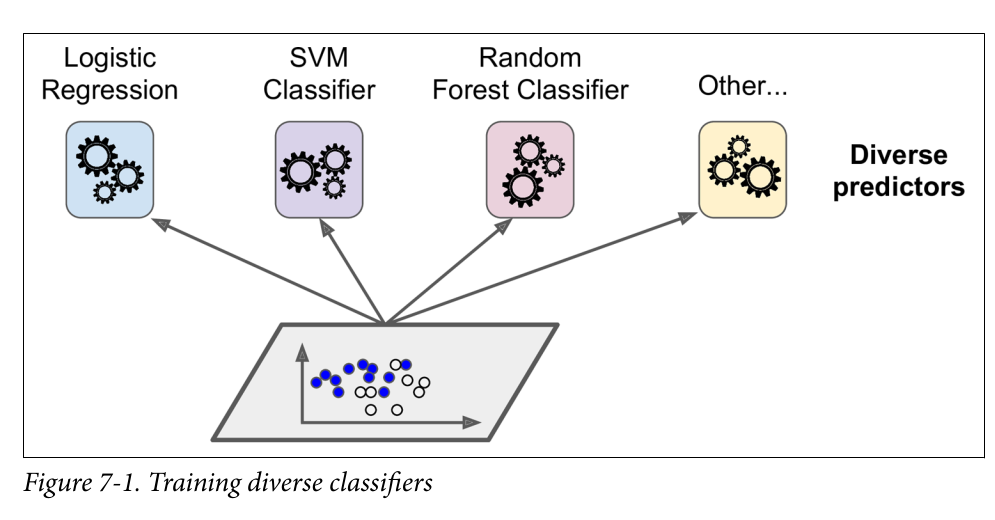
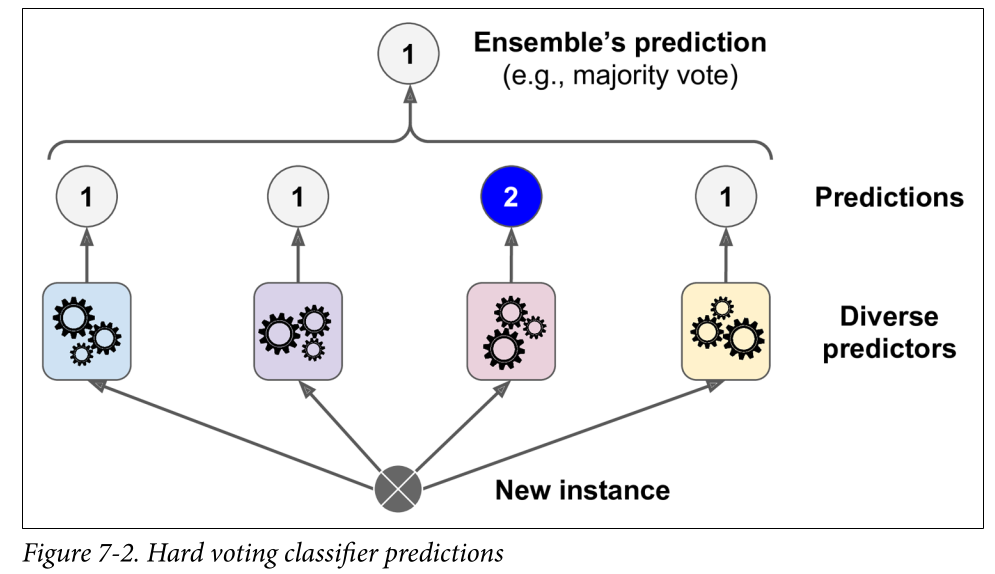

The reason why this works is best explained using the following analogy:
Image you have a coin that has a 51% chance of giving you heads, and a 49% chance of giving tails. If you toss this coin over and over again, the percentage of heads you get will slowly approach 51%, because with thousands of tosses, you essentially eliminate initial randomness. This means that the probability of getting a majority of heads increases the more you toss the coin. 

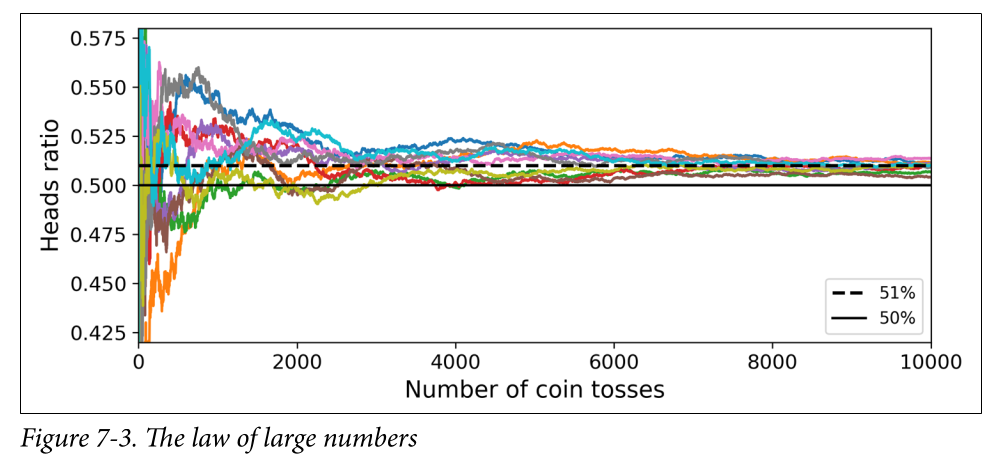

As you can see in the figure, as we toss the coins more and more times, the ratio of heads slowly approaches the true underlying probability of the coin of 51%. 

Similarly, if you have many classifiers with a probability of getting the right answer of 51% (barely better than random guessing), you can expect that using more and more classifiers will guarantee that the majority of them predict the answer correctly. However, for this approach to work, the classifiers need to make errors independantly from each other, but this cannot be the case since all the classifier are trained on the same data, which means that they tend to make the same errors. 

The solution to this problem is to train diverse classifiers that use completely different training algorithms to increase the chance that they make different errors from each other.

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
X, y = make_moons(n_samples = 1000, noise = 0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [80]:
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC(probability = True)
knn_clf = KNeighborsClassifier()

voting_clf = VotingClassifier(estimators = [
    ('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf), ('knn', knn_clf)
], voting = 'soft') #voting can be either "hard" or "soft"


In [81]:
from sklearn.metrics import accuracy_score

for clf in (log_clf, rnd_clf, svm_clf, knn_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.83
RandomForestClassifier 0.86
SVC 0.89
KNeighborsClassifier 0.89
VotingClassifier 0.89


In this case, the voting classifier didn't get a better result than the best classifier, but sometimes it does get a better result depending on the dataset and the number of classifiers used in the voting process!

__Notes:__ 
1. You can use "soft" instead of "hard" voting. The difference is that soft voting calculates the average of the probabilities output by each classifier, and selects the class with the highest overall probability to be the output. However, for this method to work, all the classifiers need to be able to output a probability, which isn't the default for the SVM, so you need to set the probability = True in the SVM constructor to make it output probabilities.
2. Soft voting is often better than hard voting because it gives more weight to confident votes.

# Bagging and Pasting
bagging and pasting are techniques that allow you to perform voting on the same classifier, while also making the individual classifiers diverse! This works by training the same classifier on different random subsets of the training set. If you do this with replacement, this algorithm is called _bagging_. If you do this without replacement, this algorithm is called _pasting_.

In other words:
1. Bagging: allows the training instances to be seen by the predictor multiple times.
2. Pasting: allows each predictor to only see a subset of the training data without repetition.

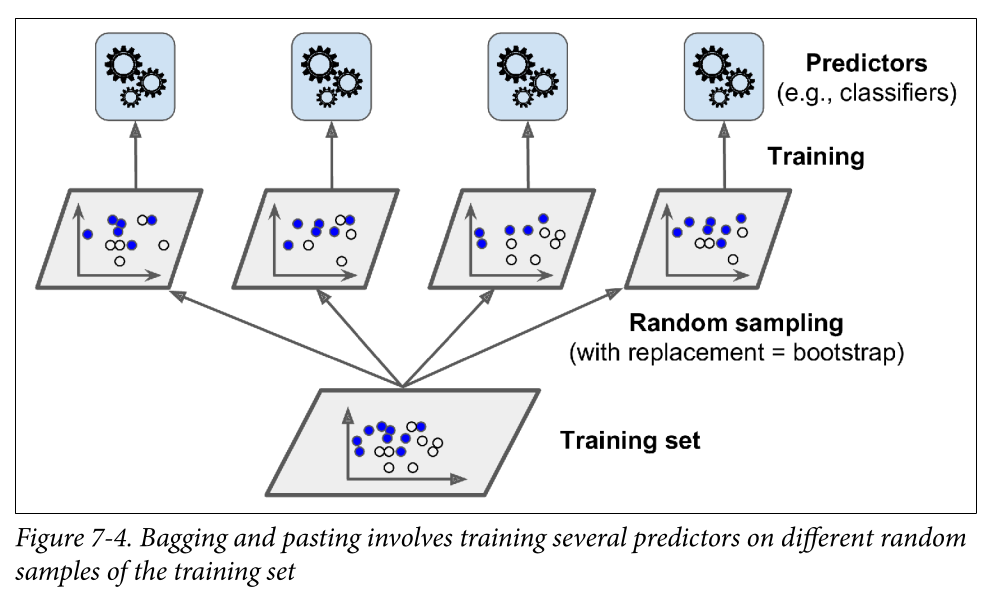

After training the predictors, we can use either hard or soft voting to get the final prediction from all the predictors. The net result is that the final model has about the same bais but lower variance than an individual predictor.

__Note:__ Bagging and pasting can utilise different CPU coes effectively, making them highly scalable!

In [82]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
bag_clf = BaggingClassifier(
    estimator = DecisionTreeClassifier(),
    n_estimators = 500,
    max_samples = 100,
    bootstrap = True, #If true, use bagging. If false, use pasting. 
    n_jobs = -1
)

bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.88

__Note:__ Bagging classifier automatically uses soft voting instead of hard voting if the estimator supports the predict_proba() method.

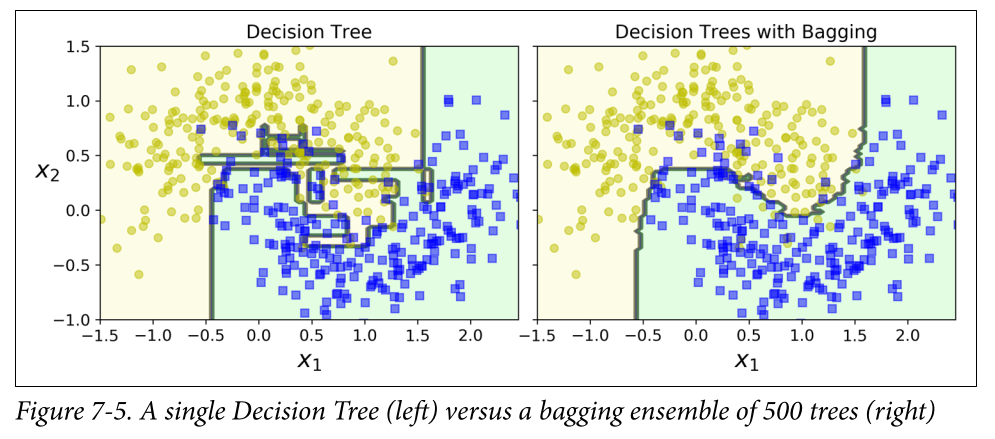

## Out-of-Bag Evaluation
Since bagging means that the same instances might be used for more than a single predictor, this means that each predictor won't see some of the training instances. These instances that won't be seen by a predictor are called _out-of-bag_, and they can be used to validate the predictor without the need for a separate validation set. The validation score of each predictor is averaged and the final result is output. To do this in scikit-learn, you can set the oob_score = True in the BaggingClassifier constructor.

In [84]:
bag_clf = BaggingClassifier(
    estimator = DecisionTreeClassifier(),
    n_estimators = 500,
    bootstrap = True,
    n_jobs = -1,
    oob_score = True
)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.885

According to the oob_score_ the classifier is supposed to achieve about 88.5% accuracy on the test set.

In [85]:
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.86

## Random Patches and Random Subspaces

BagginClassifier can also sample a subset of the features to train a number of predictors on them. This can be done by setting the the max_features and the bootstrap_features paramters. They work the same way as max_samples and bootstrap, but for features instead of instances.

If you use all the training instances (bootstrap = False, max_samples = 1.0), but only a subset of the features (setting bootstrap_features = True, and max_features < 1.0) this is called _Random Subspaces_ method.

If you sample both the features and the training instances, this is called _Random Patches_ method.

# Random Forests
Random forests uses an ensemble of decision trees via the bagging method, typically with max_samples equal to the size of the training set. The following code desmonstrates this:

In [86]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes = 16, n_jobs = -1)
rnd_clf.fit(X_train, y_train)
y_pred = rnd_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.875

__Notes:__ 
1. The random forest classifier introduces extra randomness when growing trees by instead of seaching for the best feature when splitting a node, it searches for the best features among a random subset of features.
2. You can introduce even more randomness by using the ExtraTreesClassifier, which instead of finding the best threshold in a subset of features, it finds just a random threshold in the subset of features, making it super random and quick to train, which allows for a large number of trees to be trained.
3. You have to test both RandomForestClassifier and ExtraTreesClassifier if you want to determine which one of them is better for your project.
4. You can determine the importance of a feature using RandomForestClassifier, because it looks at the tree nodes that use the feature, and it measures how much that feature reduces the impurity on average (across all trees in the forest). The following code shows how to use scikit-learn to determine the importance of a featuer:

In [87]:
from sklearn.datasets import load_iris
iris = load_iris()
rnd_clf = RandomForestClassifier(n_estimators=500, n_jobs = -1)
rnd_clf.fit(iris['data'], iris['target'])
for name, score in zip(iris['feature_names'], rnd_clf.feature_importances_):
    print(name, score)

sepal length (cm) 0.09893461358639577
sepal width (cm) 0.023130166429699606
petal length (cm) 0.4377323655674003
petal width (cm) 0.44020285441650436


We can clearly see that the most important features are petal length 43.773% and petal width 44.02%, while the sepal length and width are not as important (9.8% and 2.3%, respectively).

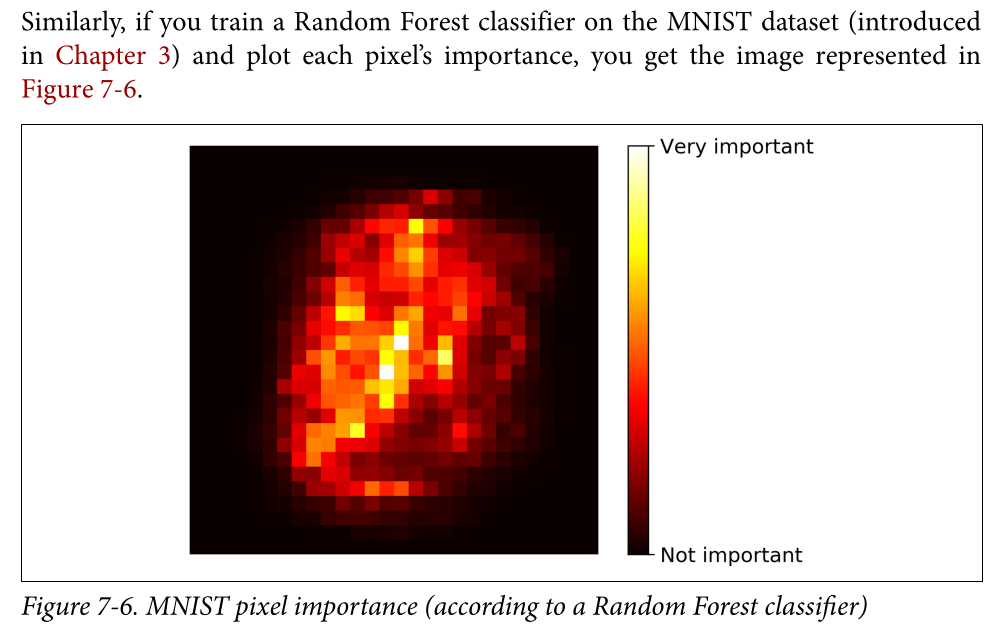

__Note:__ If you want to perform feature selection, you should use random forests to quickly understand which features are most important to keep them and get rid of the less important ones.

# Boosting
Boosing refers to any ensemble method that can combine several weak learners into a strong learner. The idea is to train predictors sequentially, each trying to correct its predecessor. The main boosting algorithms used are AdaBoost (adaptive boosting) and Gradient Boosting.

## AdaBoost

AdaBoost works by training a classifier that focuses on the mistakes its predecessor has made. The algorithm first trains a base classifier (such as a Decision Tree) and uses it to make predictions on the training set. The algorithms increases the relative weight of misclassified training instances, and it trains a second classifier, using the updated weights, and against makes predictions on the training set, updates the instance weights, and so on. 

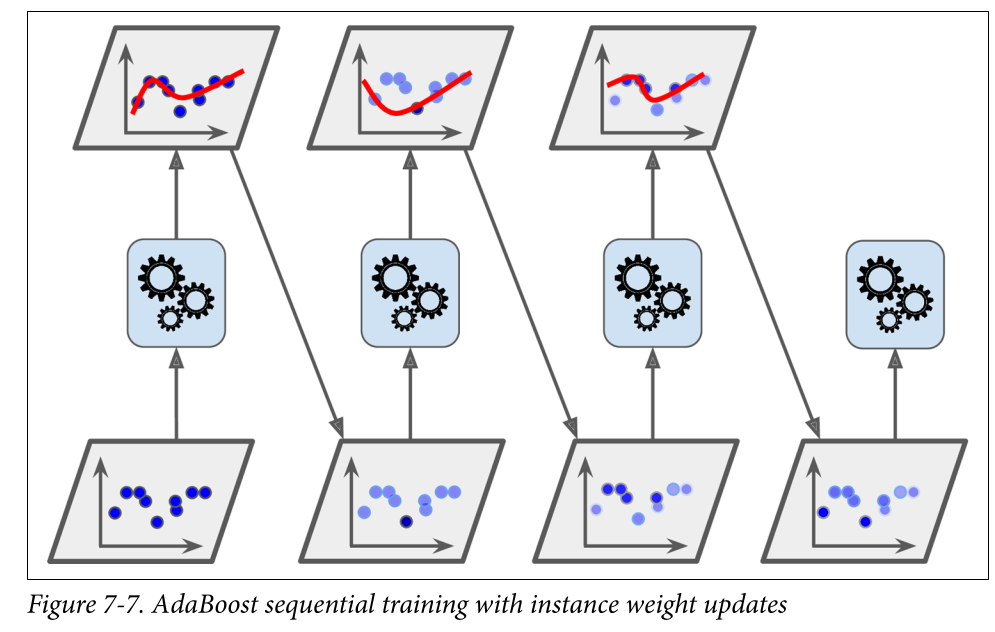

AdaBoost works as follows:
1. Initially, each instance weight $w^{(i)}$ is set to $\frac{1}{m}$.
2. A first predictor is trained, and its weighted error rate $r_{1}$ is computed on the training set.

    Weighted error for the $j^{th}$ predictor:
    
    $r_{j} = \frac{\sum_{i = 1}^{m} (w^{(i)})\ where\ \hat{y}^{(i)} \neq y^{(i)}}{\sum_{i = 1}^{m} w^{(i)}}$

3. The predictors weight $\alpha_j$ is computed using:

    $\alpha_j = \eta log(\frac{1 - r_j}{r_j})$

4. Next, the AdaBoost algorithm updates the instance weight using:

    $w^{(i)} = w^{(i)}\ if\ \hat{y}^{(i)} = y^{(i)}$
    
    $w^{(i)} = w^{(i)}exp(\alpha_j)\ if\ \hat{y}^{(i)} \neq y^{(i)}$

    After the update, all the instance weights are normalized <br> (i.e. divided by $\sum_{i = 1}^{m}w^{(i)}$)

5. Finally, a new predictor is trained using the updated weights, and the whole process is repeated. The algorithm stops when the desired number of predictors is reached, or when a perfect predictor is found.

__Note:__ To make predictions, AdaBoost simply computes the predictions of all the predictors and weighs then using the predictor weights $\alpha_j$.

$\hat{y}(x) = argmax \sum_{j = 1}^{N}\alpha_j$ where $N$ is the number of predictors.

For more information about AdaBoost, check the following video:
https://www.youtube.com/watch?v=LsK-xG1cLYA

In [89]:
from sklearn.ensemble import AdaBoostClassifier
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth = 1),
    n_estimators = 200,
    algorithm = 'SAMME',
    learning_rate = 0.5
)

ada_clf.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=200)

In [90]:
y_pred = ada_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.87

## Gradient Boosting
This works by fitting a new predictor to the residual errors of the previous predictor, and adding the outputs to get the final prediction.

The following code best expains this:

In [100]:
from sklearn.tree import DecisionTreeClassifier
#train the base model
tree_reg1 = DecisionTreeClassifier(max_depth = 2)
tree_reg1.fit(X_train, y_train)

#train a second model that can predict the errors of the first one
y2 = y_train - tree_reg1.predict(X_train) 
tree_reg2 = DecisionTreeClassifier(max_depth = 2)
tree_reg2.fit(X_train, y2)

#train a third model that can predict the erros of the second one
y3 = y2 - tree_reg2.predict(X_train)
tree_reg3 = DecisionTreeClassifier(max_depth = 2)
tree_reg3.fit(X_train, y3)

#the final prediction is equal to the sum of the predictions of all the models
y_pred_train = sum(tree.predict(X_train) for tree in (tree_reg1, tree_reg2, tree_reg3))
print('Training accuracy: ', accuracy_score(y_train, y_pred_train))

y_pred_test = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3))
print('Testing accuracy: ', accuracy_score(y_test, y_pred_test))

Training accuracy:  0.89875
Testing accuracy:  0.88


In [102]:
#sklearn implementation
from sklearn.ensemble import GradientBoostingClassifier
gbrt = GradientBoostingClassifier(max_depth = 2, n_estimators=3, learning_rate = 1)
gbrt.fit(X_train, y_train)
y_pred = gbrt.predict(X_test)
accuracy_score(y_test, y_pred)

0.885

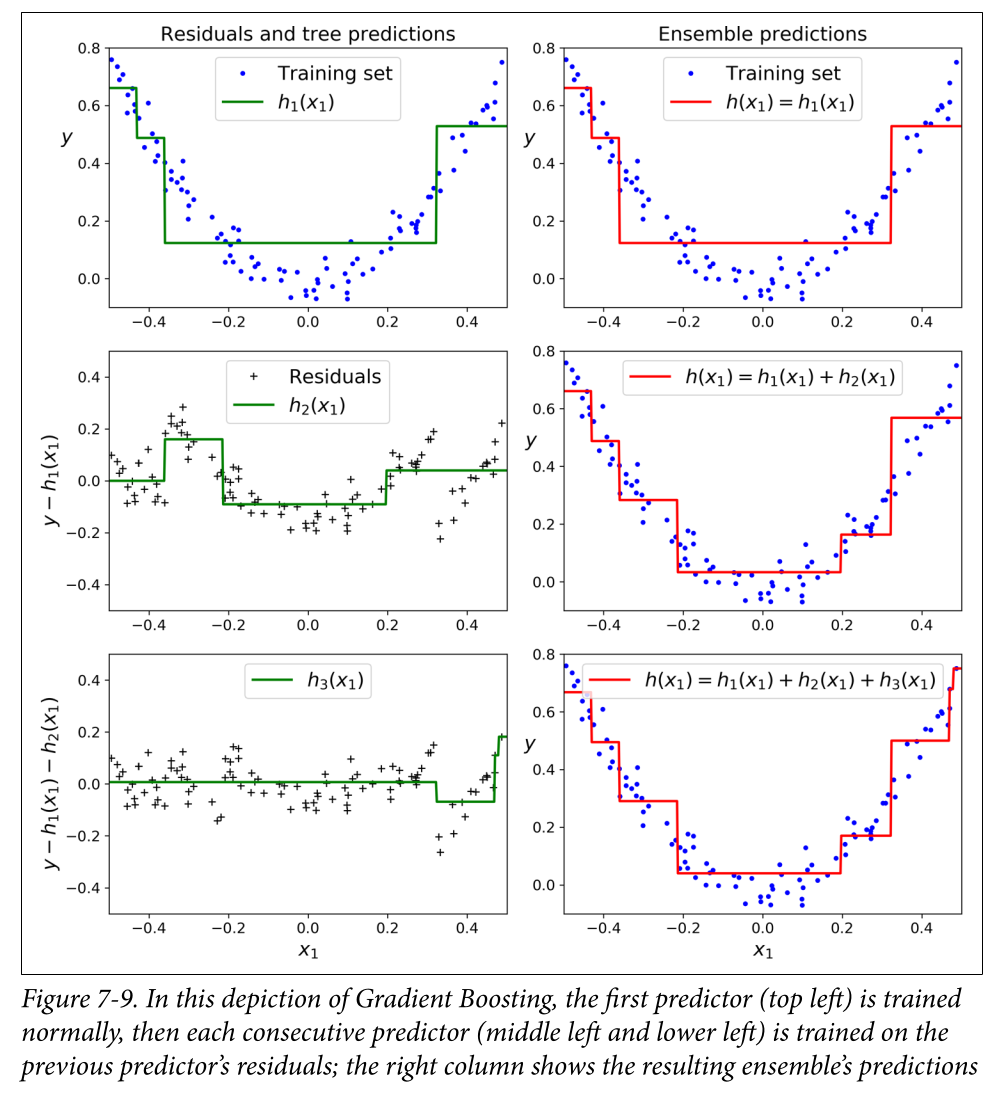

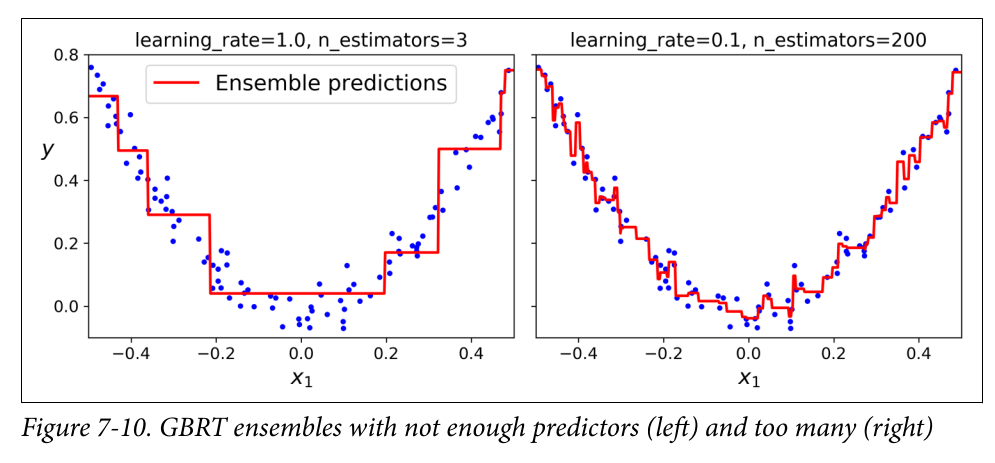

__Note:__ The learning rate determines the contribution of each prediction. Setting it to a low value means that you need more trees to get a good result!

In [133]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from matplotlib import pyplot as plt

m = 100
X = np.linspace(-4, 4, m)
y = 1/16 * X**2 + np.random.randn(m)*1/16
X = np.expand_dims(X, axis = -1)
y = np.expand_dims(y, axis = -1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

gbrt = GradientBoostingRegressor(max_depth = 2, n_estimators=120)
gbrt.fit(X_train, y_train.ravel())

errors = [mean_squared_error(y_test, y_pred) for y_pred in gbrt.staged_predict(X_test)]
best_number_of_estimators = np.argmin(errors) + 1 #indexing starts at 0

gbrt_best = GradientBoostingRegressor(max_depth=2, n_estimators=best_number_of_estimators)
gbrt_best.fit(X_train, y_train.ravel())

GradientBoostingRegressor(max_depth=2, n_estimators=45)

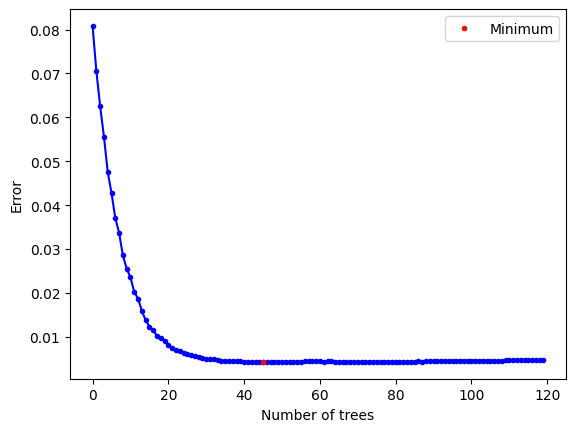

In [134]:
plt.plot(errors, 'b.-')
plt.plot(best_number_of_estimators, errors[best_number_of_estimators-1], 'r.', label = 'Minimum')
plt.legend(loc = 'best')
plt.xlabel('Number of trees')
plt.ylabel('Error')
plt.show()

You can also run a for loop that stops training when the error goes up for a specified amount of iterations as follows:

In [135]:
gbrt = GradientBoostingRegressor(max_depth = 2, warm_start = True ) #warm start keeps existing trees when the fit() is called
min_test_error = float('inf')
error_iteration_limit = 10 #if the error goes up this many times in a row, stop training.
error_going_up = 0
for n_estimators in range(1, 120):
    gbrt.n_estimators_ = n_estimators
    gbrt.fit(X_train, y_train.ravel())
    y_pred = gbrt.predict(X_test)
    test_error = mean_squared_error(y_test, y_pred)
    if test_error < min_test_error:
        min_test_error = test_error
        error_going_up = 0
    else:
        error_going_up += 1
        if error_going_up == error_iteration_limit:
            break #stop early

In [136]:
n_estimators

11

You can also set teh subsample parameter to train each tree on a subset of the training data. This will trade a higher bias for a lower variance.

You can also use the xgboost library instead of scikit-learn because it is much faster and has many nice features implemented!

In [139]:
import xgboost

xgb_reg = xgboost.XGBRegressor()
xgb_reg.fit(X_train,y_train)
y_pred = xgb_reg.predict(X_test)
mean_squared_error(y_test, y_pred)

0.005819535287820357

# Stacking
Instead of using a trivial aggrigation method to combine the predictions of all the predictors (such as hard voting), we can train a model that performs this aggregation!

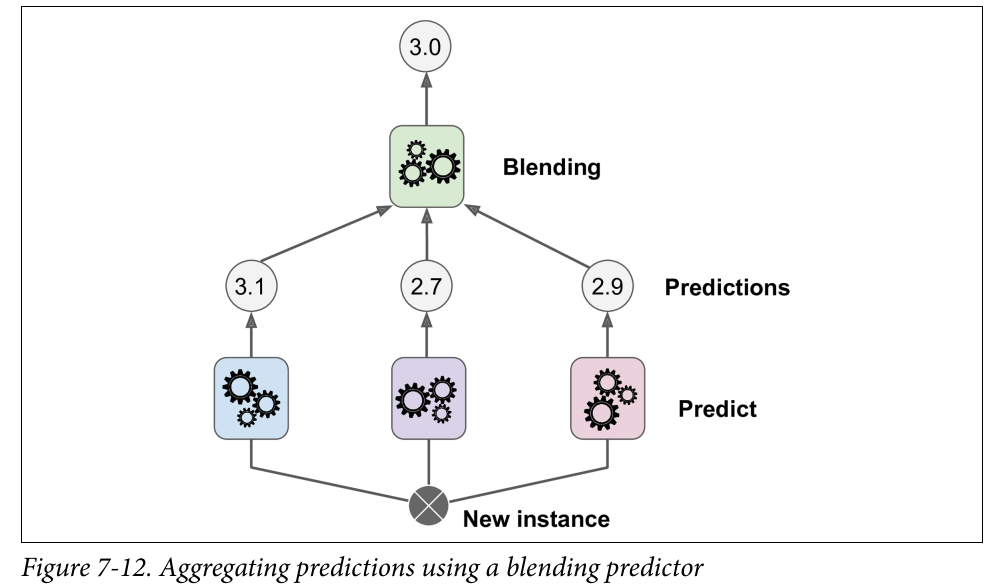

This new model is called the _blender_, which uses the predictions of the predictors in the first layer to find a final prediction for the output.

Training the blender can be done by splitting the training data into two sets. The first set is used to train the predictors in the first layer. Then, after training the first layer, each one of the classifiers in the first layer it used to predict the values on the second subset of the training data. This new subset will have as many features as there are predictors. After that, this output will be used to train the blender to combine the features from the different predictors to get the final result.

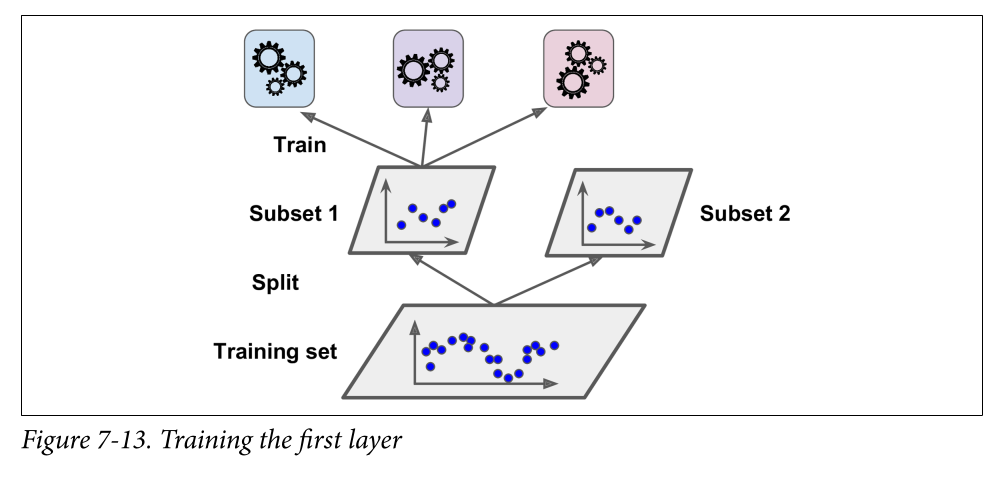

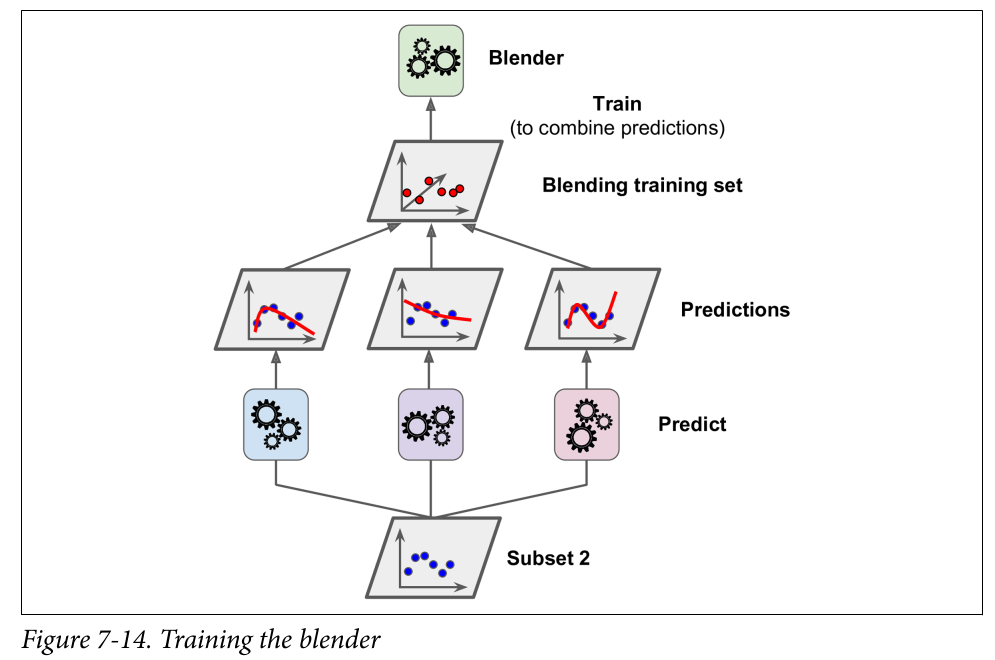

It is also possible to use more than two layers by splitting the training data into three subsets and training two layers of blenders in the same way.

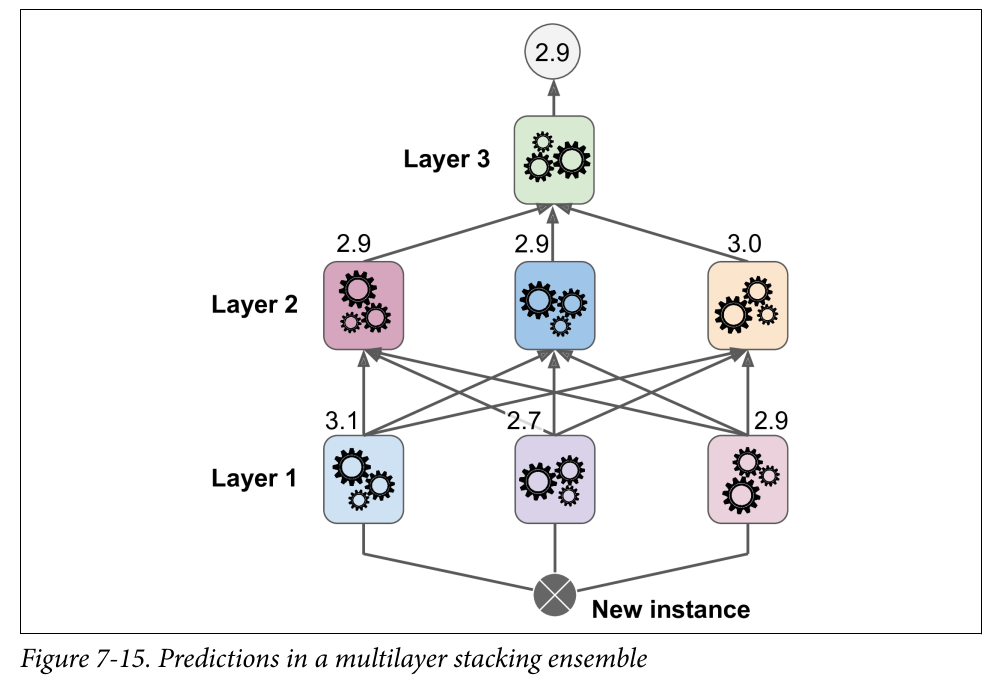

scikit-learn doesn't support stacking directly, but it isn't hard to implement it yourself.